In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder

# Define function to extract HOG features
def extract_hog_features(images):
    hog_features = []
    for image in images:
        # Convert image to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Compute HOG features
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
        hog_features.append(features)
    return np.array(hog_features)

# Load dataset and labels
def load_data(train_path, val_path, test_path):
    train_images, train_labels = load_images_from_path(train_path)
    val_images, val_labels = load_images_from_path(val_path)
    test_images, test_labels = load_images_from_path(test_path)
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

def load_images_from_path(path):
    images = []
    labels = []
    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        for filename in os.listdir(label_path):
            image_path = os.path.join(label_path, filename)
            # Load image
            image = cv2.imread(image_path)
            if image is not None:
                # Resize image to 224x224
                image = cv2.resize(image, (224, 224))
                images.append(image)
                labels.append(label)
            else:
                print("Error loading image:", image_path)
    return np.array(images), np.array(labels)

# Load dataset
train_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/train"
val_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/val"
test_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/test"
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_data(train_path, val_path, test_path)

# Split dataset into training, validation, and testing sets
X_train, y_train = train_images, train_labels
X_val, y_val = val_images, val_labels
X_test, y_test = test_images, test_labels

# Assuming train_images, train_labels, val_images, val_labels, test_images, and test_labels are numpy arrays or lists/tuples
print("Shape of training images:", X_train.shape)
print("Shape of training labels:", y_train.shape)
print("Shape of validation images:", X_val.shape)
print("Shape of validation labels:", y_val.shape)
print("Shape of test images:", X_test.shape)
print("Shape of test labels:", y_test.shape)

# Extract HOG features
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

# Perform LDA on training, validation, and testing sets
lda = LDA()  # You can adjust parameters as needed
X_train_lda = lda.fit_transform(X_train_hog, y_train)
X_val_lda = lda.transform(X_val_hog)
X_test_lda = lda.transform(X_test_hog)

# Manually specify class labels
class_labels = ['Abnormal', 'Normal']

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(class_labels)

# Transform target labels
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)


Shape of training images: (712, 224, 224, 3)
Shape of training labels: (712,)
Shape of validation images: (203, 224, 224, 3)
Shape of validation labels: (203,)
Shape of test images: (103, 224, 224, 3)
Shape of test labels: (103,)


In [2]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier
knn_classifier = KNeighborsClassifier()

# Train the classifier
knn_classifier.fit(X_train_lda, y_train_encoded)#X_train_pca #X_train_hog#X_train_lda

# Make predictions on validation set
val_predictions_knn = knn_classifier.predict(X_val_lda)# X_val_pca # X_val_hog

# Calculate accuracy on validation set
val_accuracy_knn = accuracy_score(y_val_encoded, val_predictions_knn)
print("Validation Accuracy (KNN):", val_accuracy_knn)

# Make predictions on test set
test_predictions_knn = knn_classifier.predict(X_test_lda) #X_test_pca #

# Calculate accuracy on test set
test_accuracy_knn = accuracy_score(y_test_encoded, test_predictions_knn)
print("Test Accuracy (KNN):", test_accuracy_knn)

# Calculate evaluation metrics for KNN classifier
val_precision_knn = precision_score(y_val_encoded, val_predictions_knn)
val_recall_knn = recall_score(y_val_encoded, val_predictions_knn)
val_f1_knn = f1_score(y_val_encoded, val_predictions_knn)
val_cm_knn = confusion_matrix(y_val_encoded, val_predictions_knn)

test_precision_knn = precision_score(y_test_encoded, test_predictions_knn)
test_recall_knn = recall_score(y_test_encoded, test_predictions_knn)
test_f1_knn = f1_score(y_test_encoded, test_predictions_knn)
test_cm_knn = confusion_matrix(y_test_encoded, test_predictions_knn)

# Print validation metrics for KNN classifier
print("\nValidation Metrics (KNN):")
print("Precision:", val_precision_knn)
print("Recall:", val_recall_knn)
print("F1 Score:", val_f1_knn)
print("Confusion Matrix:")
print(val_cm_knn)

# Print classification report for KNN classifier on validation set
print("\nValidation Classification Report (KNN):")
print(classification_report(y_val_encoded, val_predictions_knn, target_names=class_labels))

# Print test metrics for KNN classifier
print("\nTest Metrics (KNN):")
print("Precision:", test_precision_knn)
print("Recall:", test_recall_knn)
print("F1 Score:", test_f1_knn)
print("Confusion Matrix:")
print(test_cm_knn)

# Print classification report for KNN classifier on test set
print("\nTest Classification Report (KNN):")
print(classification_report(y_test_encoded, test_predictions_knn, target_names=class_labels))


Validation Accuracy (KNN): 0.6798029556650246
Test Accuracy (KNN): 0.7864077669902912

Validation Metrics (KNN):
Precision: 0.6547619047619048
Recall: 0.6043956043956044
F1 Score: 0.6285714285714286
Confusion Matrix:
[[83 29]
 [36 55]]

Validation Classification Report (KNN):
              precision    recall  f1-score   support

    Abnormal       0.70      0.74      0.72       112
      Normal       0.65      0.60      0.63        91

    accuracy                           0.68       203
   macro avg       0.68      0.67      0.67       203
weighted avg       0.68      0.68      0.68       203


Test Metrics (KNN):
Precision: 0.7659574468085106
Recall: 0.7659574468085106
F1 Score: 0.7659574468085105
Confusion Matrix:
[[45 11]
 [11 36]]

Test Classification Report (KNN):
              precision    recall  f1-score   support

    Abnormal       0.80      0.80      0.80        56
      Normal       0.77      0.77      0.77        47

    accuracy                           0.79       103


# KNN
* Accuracy ≈ 0.7864
* Precision ≈ 0.7659
* Recall ≈ 0.7659
* F1 Score ≈ 0.7659

In [3]:
from sklearn.svm import SVC

# Initialize SVC classifier
svc_classifier = SVC()

# Train the classifier
svc_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_svc = svc_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_svc = accuracy_score(y_val_encoded, val_predictions_svc)
print("Validation Accuracy (SVC):", val_accuracy_svc)

# Make predictions on test set
test_predictions_svc = svc_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_svc = accuracy_score(y_test_encoded, test_predictions_svc)
print("Test Accuracy (SVC):", test_accuracy_svc)

# Calculate evaluation metrics for SVC classifier
val_precision_svc = precision_score(y_val_encoded, val_predictions_svc)
val_recall_svc = recall_score(y_val_encoded, val_predictions_svc)
val_f1_svc = f1_score(y_val_encoded, val_predictions_svc)
val_cm_svc = confusion_matrix(y_val_encoded, val_predictions_svc)

test_precision_svc = precision_score(y_test_encoded, test_predictions_svc)
test_recall_svc = recall_score(y_test_encoded, test_predictions_svc)
test_f1_svc = f1_score(y_test_encoded, test_predictions_svc)
test_cm_svc = confusion_matrix(y_test_encoded, test_predictions_svc)

# Print validation metrics for SVC classifier
print("\nValidation Metrics (SVC):")
print("Precision:", val_precision_svc)
print("Recall:", val_recall_svc)
print("F1 Score:", val_f1_svc)
print("Confusion Matrix:")
print(val_cm_svc)

# Print classification report for SVC classifier on validation set
print("\nValidation Classification Report (SVC):")
print(classification_report(y_val_encoded, val_predictions_svc, target_names=class_labels))

# Print test metrics for SVC classifier
print("\nTest Metrics (SVC):")
print("Precision:", test_precision_svc)
print("Recall:", test_recall_svc)
print("F1 Score:", test_f1_svc)
print("Confusion Matrix:")
print(test_cm_svc)

# Print classification report for SVC classifier on test set
print("\nTest Classification Report (SVC):")
print(classification_report(y_test_encoded, test_predictions_svc, target_names=class_labels))


Validation Accuracy (SVC): 0.7241379310344828
Test Accuracy (SVC): 0.7766990291262136

Validation Metrics (SVC):
Precision: 0.7108433734939759
Recall: 0.6483516483516484
F1 Score: 0.67816091954023
Confusion Matrix:
[[88 24]
 [32 59]]

Validation Classification Report (SVC):
              precision    recall  f1-score   support

    Abnormal       0.73      0.79      0.76       112
      Normal       0.71      0.65      0.68        91

    accuracy                           0.72       203
   macro avg       0.72      0.72      0.72       203
weighted avg       0.72      0.72      0.72       203


Test Metrics (SVC):
Precision: 0.7608695652173914
Recall: 0.7446808510638298
F1 Score: 0.7526881720430109
Confusion Matrix:
[[45 11]
 [12 35]]

Test Classification Report (SVC):
              precision    recall  f1-score   support

    Abnormal       0.79      0.80      0.80        56
      Normal       0.76      0.74      0.75        47

    accuracy                           0.78       103
 

# SVM
* Accuracy ≈ 0.7767
* Precision ≈ 0.7609
* Recall ≈ 0.7447
* F1 Score ≈ 0.7527

In [4]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Initialize Passive Aggressive Classifier
pac_classifier = PassiveAggressiveClassifier()

# Train the classifier
pac_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_pac = pac_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_pac = accuracy_score(y_val_encoded, val_predictions_pac)
print("Validation Accuracy (Passive Aggressive Classifier):", val_accuracy_pac)

# Make predictions on test set
test_predictions_pac = pac_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_pac = accuracy_score(y_test_encoded, test_predictions_pac)
print("Test Accuracy (Passive Aggressive Classifier):", test_accuracy_pac)

# Calculate evaluation metrics for Passive Aggressive Classifier
val_precision_pac = precision_score(y_val_encoded, val_predictions_pac)
val_recall_pac = recall_score(y_val_encoded, val_predictions_pac)
val_f1_pac = f1_score(y_val_encoded, val_predictions_pac)
val_cm_pac = confusion_matrix(y_val_encoded, val_predictions_pac)

test_precision_pac = precision_score(y_test_encoded, test_predictions_pac)
test_recall_pac = recall_score(y_test_encoded, test_predictions_pac)
test_f1_pac = f1_score(y_test_encoded, test_predictions_pac)
test_cm_pac = confusion_matrix(y_test_encoded, test_predictions_pac)

# Print validation metrics for Passive Aggressive Classifier
print("\nValidation Metrics (Passive Aggressive Classifier):")
print("Precision:", val_precision_pac)
print("Recall:", val_recall_pac)
print("F1 Score:", val_f1_pac)
print("Confusion Matrix:")
print(val_cm_pac)

# Print classification report for Passive Aggressive Classifier on validation set
print("\nValidation Classification Report (Passive Aggressive Classifier):")
print(classification_report(y_val_encoded, val_predictions_pac, target_names=class_labels))

# Print test metrics for Passive Aggressive Classifier
print("\nTest Metrics (Passive Aggressive Classifier):")
print("Precision:", test_precision_pac)
print("Recall:", test_recall_pac)
print("F1 Score:", test_f1_pac)
print("Confusion Matrix:")
print(test_cm_pac)

# Print classification report for Passive Aggressive Classifier on test set
print("\nTest Classification Report (Passive Aggressive Classifier):")
print(classification_report(y_test_encoded, test_predictions_pac, target_names=class_labels))


Validation Accuracy (Passive Aggressive Classifier): 0.729064039408867
Test Accuracy (Passive Aggressive Classifier): 0.7572815533980582

Validation Metrics (Passive Aggressive Classifier):
Precision: 0.6836734693877551
Recall: 0.7362637362637363
F1 Score: 0.7089947089947091
Confusion Matrix:
[[81 31]
 [24 67]]

Validation Classification Report (Passive Aggressive Classifier):
              precision    recall  f1-score   support

    Abnormal       0.77      0.72      0.75       112
      Normal       0.68      0.74      0.71        91

    accuracy                           0.73       203
   macro avg       0.73      0.73      0.73       203
weighted avg       0.73      0.73      0.73       203


Test Metrics (Passive Aggressive Classifier):
Precision: 0.72
Recall: 0.7659574468085106
F1 Score: 0.7422680412371133
Confusion Matrix:
[[42 14]
 [11 36]]

Test Classification Report (Passive Aggressive Classifier):
              precision    recall  f1-score   support

    Abnormal       0.

# PassiveAggressive 
* Accuracy ≈ 0.7573
* Precision = 0.72
* Recall ≈ 0.7659
* F1 Score ≈ 0.7427


In [5]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()

# Train the classifier
dt_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_dt = dt_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_dt = accuracy_score(y_val_encoded, val_predictions_dt)
print("Validation Accuracy (Decision Tree Classifier):", val_accuracy_dt)

# Make predictions on test set
test_predictions_dt = dt_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_dt = accuracy_score(y_test_encoded, test_predictions_dt)
print("Test Accuracy (Decision Tree Classifier):", test_accuracy_dt)

# Calculate evaluation metrics for Decision Tree Classifier
val_precision_dt = precision_score(y_val_encoded, val_predictions_dt)
val_recall_dt = recall_score(y_val_encoded, val_predictions_dt)
val_f1_dt = f1_score(y_val_encoded, val_predictions_dt)
val_cm_dt = confusion_matrix(y_val_encoded, val_predictions_dt)

test_precision_dt = precision_score(y_test_encoded, test_predictions_dt)
test_recall_dt = recall_score(y_test_encoded, test_predictions_dt)
test_f1_dt = f1_score(y_test_encoded, test_predictions_dt)
test_cm_dt = confusion_matrix(y_test_encoded, test_predictions_dt)

# Print validation metrics for Decision Tree Classifier
print("\nValidation Metrics (Decision Tree Classifier):")
print("Precision:", val_precision_dt)
print("Recall:", val_recall_dt)
print("F1 Score:", val_f1_dt)
print("Confusion Matrix:")
print(val_cm_dt)

# Print classification report for Decision Tree Classifier on validation set
print("\nValidation Classification Report (Decision Tree Classifier):")
print(classification_report(y_val_encoded, val_predictions_dt, target_names=class_labels))

# Print test metrics for Decision Tree Classifier
print("\nTest Metrics (Decision Tree Classifier):")
print("Precision:", test_precision_dt)
print("Recall:", test_recall_dt)
print("F1 Score:", test_f1_dt)
print("Confusion Matrix:")
print(test_cm_dt)

# Print classification report for Decision Tree Classifier on test set
print("\nTest Classification Report (Decision Tree Classifier):")
print(classification_report(y_test_encoded, test_predictions_dt, target_names=class_labels))


Validation Accuracy (Decision Tree Classifier): 0.6551724137931034
Test Accuracy (Decision Tree Classifier): 0.6407766990291263

Validation Metrics (Decision Tree Classifier):
Precision: 0.6153846153846154
Recall: 0.6153846153846154
F1 Score: 0.6153846153846154
Confusion Matrix:
[[77 35]
 [35 56]]

Validation Classification Report (Decision Tree Classifier):
              precision    recall  f1-score   support

    Abnormal       0.69      0.69      0.69       112
      Normal       0.62      0.62      0.62        91

    accuracy                           0.66       203
   macro avg       0.65      0.65      0.65       203
weighted avg       0.66      0.66      0.66       203


Test Metrics (Decision Tree Classifier):
Precision: 0.5925925925925926
Recall: 0.6808510638297872
F1 Score: 0.6336633663366336
Confusion Matrix:
[[34 22]
 [15 32]]

Test Classification Report (Decision Tree Classifier):
              precision    recall  f1-score   support

    Abnormal       0.69      0.61   

# Decision Tree
* Accuracy ≈ 0.6408
* Precision ≈ 0.5926
* Recall ≈ 0.6809
* F1 Score ≈ 0.6333

In [6]:
from sklearn.neural_network import MLPClassifier

# Initialize MLPClassifier
mlp_classifier = MLPClassifier()

# Train the classifier
mlp_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_mlp = mlp_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_mlp = accuracy_score(y_val_encoded, val_predictions_mlp)
print("Validation Accuracy (MLPClassifier):", val_accuracy_mlp)

# Make predictions on test set
test_predictions_mlp = mlp_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_mlp = accuracy_score(y_test_encoded, test_predictions_mlp)
print("Test Accuracy (MLPClassifier):", test_accuracy_mlp)

# Calculate evaluation metrics for MLPClassifier
val_precision_mlp = precision_score(y_val_encoded, val_predictions_mlp)
val_recall_mlp = recall_score(y_val_encoded, val_predictions_mlp)
val_f1_mlp = f1_score(y_val_encoded, val_predictions_mlp)
val_cm_mlp = confusion_matrix(y_val_encoded, val_predictions_mlp)

test_precision_mlp = precision_score(y_test_encoded, test_predictions_mlp)
test_recall_mlp = recall_score(y_test_encoded, test_predictions_mlp)
test_f1_mlp = f1_score(y_test_encoded, test_predictions_mlp)
test_cm_mlp = confusion_matrix(y_test_encoded, test_predictions_mlp)

# Print validation metrics for MLPClassifier
print("\nValidation Metrics (MLPClassifier):")
print("Precision:", val_precision_mlp)
print("Recall:", val_recall_mlp)
print("F1 Score:", val_f1_mlp)
print("Confusion Matrix:")
print(val_cm_mlp)

# Print classification report for MLPClassifier on validation set
print("\nValidation Classification Report (MLPClassifier):")
print(classification_report(y_val_encoded, val_predictions_mlp, target_names=class_labels))

# Print test metrics for MLPClassifier
print("\nTest Metrics (MLPClassifier):")
print("Precision:", test_precision_mlp)
print("Recall:", test_recall_mlp)
print("F1 Score:", test_f1_mlp)
print("Confusion Matrix:")
print(test_cm_mlp)

# Print classification report for MLPClassifier on test set
print("\nTest Classification Report (MLPClassifier):")
print(classification_report(y_test_encoded, test_predictions_mlp, target_names=class_labels))


Validation Accuracy (MLPClassifier): 0.7142857142857143
Test Accuracy (MLPClassifier): 0.7669902912621359

Validation Metrics (MLPClassifier):
Precision: 0.6896551724137931
Recall: 0.6593406593406593
F1 Score: 0.6741573033707866
Confusion Matrix:
[[85 27]
 [31 60]]

Validation Classification Report (MLPClassifier):
              precision    recall  f1-score   support

    Abnormal       0.73      0.76      0.75       112
      Normal       0.69      0.66      0.67        91

    accuracy                           0.71       203
   macro avg       0.71      0.71      0.71       203
weighted avg       0.71      0.71      0.71       203


Test Metrics (MLPClassifier):
Precision: 0.7446808510638298
Recall: 0.7446808510638298
F1 Score: 0.7446808510638298
Confusion Matrix:
[[44 12]
 [12 35]]

Test Classification Report (MLPClassifier):
              precision    recall  f1-score   support

    Abnormal       0.79      0.79      0.79        56
      Normal       0.74      0.74      0.74     

# MLP 
* Accuracy ≈ 0.7660
* Precision ≈ 0.7447
* Recall ≈ 0.7447
* F1 Score ≈ 0.7447

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier()

# Train the classifier
rf_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_rf = rf_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_rf = accuracy_score(y_val_encoded, val_predictions_rf)
print("Validation Accuracy (RandomForestClassifier):", val_accuracy_rf)

# Make predictions on test set
test_predictions_rf = rf_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_rf = accuracy_score(y_test_encoded, test_predictions_rf)
print("Test Accuracy (RandomForestClassifier):", test_accuracy_rf)

# Calculate evaluation metrics for RandomForestClassifier
val_precision_rf = precision_score(y_val_encoded, val_predictions_rf)
val_recall_rf = recall_score(y_val_encoded, val_predictions_rf)
val_f1_rf = f1_score(y_val_encoded, val_predictions_rf)
val_cm_rf = confusion_matrix(y_val_encoded, val_predictions_rf)

test_precision_rf = precision_score(y_test_encoded, test_predictions_rf)
test_recall_rf = recall_score(y_test_encoded, test_predictions_rf)
test_f1_rf = f1_score(y_test_encoded, test_predictions_rf)
test_cm_rf = confusion_matrix(y_test_encoded, test_predictions_rf)

# Print validation metrics for RandomForestClassifier
print("\nValidation Metrics (RandomForestClassifier):")
print("Precision:", val_precision_rf)
print("Recall:", val_recall_rf)
print("F1 Score:", val_f1_rf)
print("Confusion Matrix:")
print(val_cm_rf)

# Print classification report for RandomForestClassifier on validation set
print("\nValidation Classification Report (RandomForestClassifier):")
print(classification_report(y_val_encoded, val_predictions_rf, target_names=class_labels))

# Print test metrics for RandomForestClassifier
print("\nTest Metrics (RandomForestClassifier):")
print("Precision:", test_precision_rf)
print("Recall:", test_recall_rf)
print("F1 Score:", test_f1_rf)
print("Confusion Matrix:")
print(test_cm_rf)

# Print classification report for RandomForestClassifier on test set
print("\nTest Classification Report (RandomForestClassifier):")
print(classification_report(y_test_encoded, test_predictions_rf, target_names=class_labels))


Validation Accuracy (RandomForestClassifier): 0.6551724137931034
Test Accuracy (RandomForestClassifier): 0.6407766990291263

Validation Metrics (RandomForestClassifier):
Precision: 0.6153846153846154
Recall: 0.6153846153846154
F1 Score: 0.6153846153846154
Confusion Matrix:
[[77 35]
 [35 56]]

Validation Classification Report (RandomForestClassifier):
              precision    recall  f1-score   support

    Abnormal       0.69      0.69      0.69       112
      Normal       0.62      0.62      0.62        91

    accuracy                           0.66       203
   macro avg       0.65      0.65      0.65       203
weighted avg       0.66      0.66      0.66       203


Test Metrics (RandomForestClassifier):
Precision: 0.5925925925925926
Recall: 0.6808510638297872
F1 Score: 0.6336633663366336
Confusion Matrix:
[[34 22]
 [15 32]]

Test Classification Report (RandomForestClassifier):
              precision    recall  f1-score   support

    Abnormal       0.69      0.61      0.65     

# RandomForest
* Accuracy ≈ 0.6408
* Precision ≈ 0.5926
* Recall ≈ 0.6809
* F1 Score ≈ 0.6333

In [8]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize HistGradientBoostingClassifier
hgb_classifier = HistGradientBoostingClassifier()

# Train the classifier
hgb_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_hgb = hgb_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_hgb = accuracy_score(y_val_encoded, val_predictions_hgb)
print("Validation Accuracy (HistGradientBoostingClassifier):", val_accuracy_hgb)

# Make predictions on test set
test_predictions_hgb = hgb_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_hgb = accuracy_score(y_test_encoded, test_predictions_hgb)
print("Test Accuracy (HistGradientBoostingClassifier):", test_accuracy_hgb)

# Calculate evaluation metrics for HistGradientBoostingClassifier
val_precision_hgb = precision_score(y_val_encoded, val_predictions_hgb)
val_recall_hgb = recall_score(y_val_encoded, val_predictions_hgb)
val_f1_hgb = f1_score(y_val_encoded, val_predictions_hgb)
val_cm_hgb = confusion_matrix(y_val_encoded, val_predictions_hgb)

test_precision_hgb = precision_score(y_test_encoded, test_predictions_hgb)
test_recall_hgb = recall_score(y_test_encoded, test_predictions_hgb)
test_f1_hgb = f1_score(y_test_encoded, test_predictions_hgb)
test_cm_hgb = confusion_matrix(y_test_encoded, test_predictions_hgb)

# Print validation metrics for HistGradientBoostingClassifier
print("\nValidation Metrics (HistGradientBoostingClassifier):")
print("Precision:", val_precision_hgb)
print("Recall:", val_recall_hgb)
print("F1 Score:", val_f1_hgb)
print("Confusion Matrix:")
print(val_cm_hgb)

# Print classification report for HistGradientBoostingClassifier on validation set
print("\nValidation Classification Report (HistGradientBoostingClassifier):")
print(classification_report(y_val_encoded, val_predictions_hgb, target_names=class_labels))

# Print test metrics for HistGradientBoostingClassifier
print("\nTest Metrics (HistGradientBoostingClassifier):")
print("Precision:", test_precision_hgb)
print("Recall:", test_recall_hgb)
print("F1 Score:", test_f1_hgb)
print("Confusion Matrix:")
print(test_cm_hgb)

# Print classification report for HistGradientBoostingClassifier on test set
print("\nTest Classification Report (HistGradientBoostingClassifier):")
print(classification_report(y_test_encoded, test_predictions_hgb, target_names=class_labels))


/opt/conda/lib/python3.10/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Validation Accuracy (HistGradientBoostingClassifier): 0.6748768472906403
Test Accuracy (HistGradientBoostingClassifier): 0.7766990291262136

Validation Metrics (HistGradientBoostingClassifier):
Precision: 0.6623376623376623
Recall: 0.5604395604395604
F1 Score: 0.6071428571428572
Confusion Matrix:
[[86 26]
 [40 51]]

Validation Classification Report (HistGradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.68      0.77      0.72       112
      Normal       0.66      0.56      0.61        91

    accuracy                           0.67       203
   macro avg       0.67      0.66      0.66       203
weighted avg       0.67      0.67      0.67       203


Test Metrics (HistGradientBoostingClassifier):
Precision: 0.7727272727272727
Recall: 0.723404255319149
F1 Score: 0.7472527472527473
Confusion Matrix:
[[46 10]
 [13 34]]

Test Classification Report (HistGradientBoostingClassifier):
              precision    recall  f1-score   support

 


# HistGradientBoosting
* Accuracy ≈ 0.7767
* Precision ≈ 0.7727
* Recall ≈ 0.7234
* F1 Score ≈ 0.7477

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier()

# Train the classifier
gb_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_gb = gb_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_gb = accuracy_score(y_val_encoded, val_predictions_gb)
print("Validation Accuracy (GradientBoostingClassifier):", val_accuracy_gb)

# Make predictions on test set
test_predictions_gb = gb_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_gb = accuracy_score(y_test_encoded, test_predictions_gb)
print("Test Accuracy (GradientBoostingClassifier):", test_accuracy_gb)

# Calculate evaluation metrics for GradientBoostingClassifier
val_precision_gb = precision_score(y_val_encoded, val_predictions_gb)
val_recall_gb = recall_score(y_val_encoded, val_predictions_gb)
val_f1_gb = f1_score(y_val_encoded, val_predictions_gb)
val_cm_gb = confusion_matrix(y_val_encoded, val_predictions_gb)

test_precision_gb = precision_score(y_test_encoded, test_predictions_gb)
test_recall_gb = recall_score(y_test_encoded, test_predictions_gb)
test_f1_gb = f1_score(y_test_encoded, test_predictions_gb)
test_cm_gb = confusion_matrix(y_test_encoded, test_predictions_gb)

# Print validation metrics for GradientBoostingClassifier
print("\nValidation Metrics (GradientBoostingClassifier):")
print("Precision:", val_precision_gb)
print("Recall:", val_recall_gb)
print("F1 Score:", val_f1_gb)
print("Confusion Matrix:")
print(val_cm_gb)

# Print classification report for GradientBoostingClassifier on validation set
print("\nValidation Classification Report (GradientBoostingClassifier):")
print(classification_report(y_val_encoded, val_predictions_gb, target_names=class_labels))

# Print test metrics for GradientBoostingClassifier
print("\nTest Metrics (GradientBoostingClassifier):")
print("Precision:", test_precision_gb)
print("Recall:", test_recall_gb)
print("F1 Score:", test_f1_gb)
print("Confusion Matrix:")
print(test_cm_gb)

# Print classification report for GradientBoostingClassifier on test set
print("\nTest Classification Report (GradientBoostingClassifier):")
print(classification_report(y_test_encoded, test_predictions_gb, target_names=class_labels))


Validation Accuracy (GradientBoostingClassifier): 0.6896551724137931
Test Accuracy (GradientBoostingClassifier): 0.7572815533980582

Validation Metrics (GradientBoostingClassifier):
Precision: 0.6555555555555556
Recall: 0.6483516483516484
F1 Score: 0.6519337016574586
Confusion Matrix:
[[81 31]
 [32 59]]

Validation Classification Report (GradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.72      0.72      0.72       112
      Normal       0.66      0.65      0.65        91

    accuracy                           0.69       203
   macro avg       0.69      0.69      0.69       203
weighted avg       0.69      0.69      0.69       203


Test Metrics (GradientBoostingClassifier):
Precision: 0.7291666666666666
Recall: 0.7446808510638298
F1 Score: 0.7368421052631579
Confusion Matrix:
[[43 13]
 [12 35]]

Test Classification Report (GradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.78 

# GradientBoosting
* Accuracy ≈ 0.7573
* Precision ≈ 0.7292
* Recall ≈ 0.7447
* F1 Score ≈ 0.7368

In [10]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize AdaBoostClassifier
ada_classifier = AdaBoostClassifier()

# Train the classifier
ada_classifier.fit(X_train_lda, y_train_encoded)

# Make predictions on validation set
val_predictions_ada = ada_classifier.predict(X_val_lda)

# Calculate accuracy on validation set
val_accuracy_ada = accuracy_score(y_val_encoded, val_predictions_ada)
print("Validation Accuracy (AdaBoostClassifier):", val_accuracy_ada)

# Make predictions on test set
test_predictions_ada = ada_classifier.predict(X_test_lda)

# Calculate accuracy on test set
test_accuracy_ada = accuracy_score(y_test_encoded, test_predictions_ada)
print("Test Accuracy (AdaBoostClassifier):", test_accuracy_ada)

# Calculate evaluation metrics for AdaBoostClassifier
val_precision_ada = precision_score(y_val_encoded, val_predictions_ada)
val_recall_ada = recall_score(y_val_encoded, val_predictions_ada)
val_f1_ada = f1_score(y_val_encoded, val_predictions_ada)
val_cm_ada = confusion_matrix(y_val_encoded, val_predictions_ada)

test_precision_ada = precision_score(y_test_encoded, test_predictions_ada)
test_recall_ada = recall_score(y_test_encoded, test_predictions_ada)
test_f1_ada = f1_score(y_test_encoded, test_predictions_ada)
test_cm_ada = confusion_matrix(y_test_encoded, test_predictions_ada)

# Print validation metrics for AdaBoostClassifier
print("\nValidation Metrics (AdaBoostClassifier):")
print("Precision:", val_precision_ada)
print("Recall:", val_recall_ada)
print("F1 Score:", val_f1_ada)
print("Confusion Matrix:")
print(val_cm_ada)

# Print classification report for AdaBoostClassifier on validation set
print("\nValidation Classification Report (AdaBoostClassifier):")
print(classification_report(y_val_encoded, val_predictions_ada, target_names=class_labels))

# Print test metrics for AdaBoostClassifier
print("\nTest Metrics (AdaBoostClassifier):")
print("Precision:", test_precision_ada)
print("Recall:", test_recall_ada)
print("F1 Score:", test_f1_ada)
print("Confusion Matrix:")
print(test_cm_ada)

# Print classification report for AdaBoostClassifier on test set
print("\nTest Classification Report (AdaBoostClassifier):")
print(classification_report(y_test_encoded, test_predictions_ada, target_names=class_labels))


Validation Accuracy (AdaBoostClassifier): 0.7192118226600985
Test Accuracy (AdaBoostClassifier): 0.7669902912621359

Validation Metrics (AdaBoostClassifier):
Precision: 0.6770833333333334
Recall: 0.7142857142857143
F1 Score: 0.6951871657754011
Confusion Matrix:
[[81 31]
 [26 65]]

Validation Classification Report (AdaBoostClassifier):
              precision    recall  f1-score   support

    Abnormal       0.76      0.72      0.74       112
      Normal       0.68      0.71      0.70        91

    accuracy                           0.72       203
   macro avg       0.72      0.72      0.72       203
weighted avg       0.72      0.72      0.72       203


Test Metrics (AdaBoostClassifier):
Precision: 0.7346938775510204
Recall: 0.7659574468085106
F1 Score: 0.7499999999999999
Confusion Matrix:
[[43 13]
 [11 36]]

Test Classification Report (AdaBoostClassifier):
              precision    recall  f1-score   support

    Abnormal       0.80      0.77      0.78        56
      Normal      

# AdaBoost
* Accuracy ≈ 0.7660
* Precision ≈ 0.7347
* Recall ≈ 0.7659
* F1 Score ≈ 0.7500

In [37]:
from sklearn.linear_model import PassiveAggressiveClassifier  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train Passive Aggressive classifier
pa_classifier = PassiveAggressiveClassifier(random_state=42)
pa_classifier.fit(train_hog_features, train_encoded_labels)

# Predictions on validation set
val_pred_pa = pa_classifier.predict(val_hog_features)

# Evaluate performance on validation set
val_accuracy_pa = accuracy_score(val_encoded_labels, val_pred_pa)
val_precision_pa = precision_score(val_encoded_labels, val_pred_pa, average='macro')
val_recall_pa = recall_score(val_encoded_labels, val_pred_pa, average='macro')
val_f1_pa = f1_score(val_encoded_labels, val_pred_pa, average='macro')
conf_matrix_pa = confusion_matrix(val_encoded_labels, val_pred_pa)
class_report_pa = classification_report(val_encoded_labels, val_pred_pa)

print("Validation Metrics (Passive Aggressive):")
print("Accuracy:", val_accuracy_pa)
print("Precision:", val_precision_pa)
print("Recall:", val_recall_pa)
print("F1 Score:", val_f1_pa)
print("Confusion Matrix:\n", conf_matrix_pa)
print("Classification Report:\n", class_report_pa)

# Predictions on test set
test_pred_pa = pa_classifier.predict(test_hog_features)

# Evaluate performance on test set
test_accuracy_pa = accuracy_score(test_encoded_labels, test_pred_pa)
test_precision_pa = precision_score(test_encoded_labels, test_pred_pa, average='macro')
test_recall_pa = recall_score(test_encoded_labels, test_pred_pa, average='macro')
test_f1_pa = f1_score(test_encoded_labels, test_pred_pa, average='macro')
conf_matrix_pa = confusion_matrix(test_encoded_labels, test_pred_pa)
class_report_pa = classification_report(test_encoded_labels, test_pred_pa)

print("\nTest Metrics (Passive Aggressive):")
print("Accuracy:", test_accuracy_pa)
print("Precision:", test_precision_pa)
print("Recall:", test_recall_pa)
print("F1 Score:", test_f1_pa)
print("Confusion Matrix:\n", conf_matrix_pa)
print("Classification Report:\n", class_report_pa)


Validation Metrics (Passive Aggressive):
Accuracy: 0.9113300492610837
Precision: 0.9157128514056225
Recall: 0.90625
F1 Score: 0.9094827586206897
Confusion Matrix:
 [[107   5]
 [ 13  78]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       112
           1       0.94      0.86      0.90        91

    accuracy                           0.91       203
   macro avg       0.92      0.91      0.91       203
weighted avg       0.91      0.91      0.91       203


Test Metrics (Passive Aggressive):
Accuracy: 0.883495145631068
Precision: 0.8831070889894419
Recall: 0.8860182370820668
F1 Score: 0.8832199546485261
Confusion Matrix:
 [[48  8]
 [ 4 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89        56
           1       0.84      0.91      0.88        47

    accuracy                           0.88       103
   macro avg       0.88      0.8

In [6]:
# Extract HOG features
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

# Perform LDA on training, validation, and testing sets
lda = LDA()  # You can adjust parameters as needed
X_train_lda = lda.fit_transform(X_train_hog, y_train)
X_val_lda = lda.transform(X_val_hog)
X_test_lda = lda.transform(X_test_hog)

# Train Logistic Regression classifier
lr_classifier = LogisticRegression(random_state=42)
lr_classifier.fit(X_train_lda, y_train)

# Predictions on validation set
val_pred_lr = lr_classifier.predict(X_val_lda)

# Evaluate performance on validation set
val_accuracy_lr = accuracy_score(y_val, val_pred_lr)
val_precision_lr = precision_score(y_val, val_pred_lr, average='macro')
val_recall_lr = recall_score(y_val, val_pred_lr, average='macro')
val_f1_lr = f1_score(y_val, val_pred_lr, average='macro')
conf_matrix_lr = confusion_matrix(y_val, val_pred_lr)
class_report_lr = classification_report(y_val, val_pred_lr)

print("Validation Metrics (Logistic Regression):")
print("Accuracy:", val_accuracy_lr)
print("Precision:", val_precision_lr)
print("Recall:", val_recall_lr)
print("F1 Score:", val_f1_lr)
print("Confusion Matrix:\n", conf_matrix_lr)
print("Classification Report:\n", class_report_lr)

# Predictions on test set
test_pred_lr = lr_classifier.predict(X_test_lda)

# Evaluate performance on test set
test_accuracy_lr = accuracy_score(y_test, test_pred_lr)
test_precision_lr = precision_score(y_test, test_pred_lr, average='macro')
test_recall_lr = recall_score(y_test, test_pred_lr, average='macro')
test_f1_lr = f1_score(y_test, test_pred_lr, average='macro')
conf_matrix_lr = confusion_matrix(y_test, test_pred_lr)
class_report_lr = classification_report(y_test, test_pred_lr)

print("\nTest Metrics (Logistic Regression):")
print("Accuracy:", test_accuracy_lr)
print("Precision:", test_precision_lr)
print("Recall:", test_recall_lr)
print("F1 Score:", test_f1_lr)
print("Confusion Matrix:\n", conf_matrix_lr)
print("Classification Report:\n", class_report_lr)

# Manually specify class labels
class_labels = ['Abnormal', 'Normal']

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(class_labels)

# Transform target labels
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

Validation Metrics (Logistic Regression):
Accuracy: 0.7142857142857143
Precision: 0.7125075895567698
Recall: 0.706043956043956
F1 Score: 0.7074637249055853
Confusion Matrix:
 [[88 24]
 [34 57]]
Classification Report:
               precision    recall  f1-score   support

    Abnormal       0.72      0.79      0.75       112
      Normal       0.70      0.63      0.66        91

    accuracy                           0.71       203
   macro avg       0.71      0.71      0.71       203
weighted avg       0.71      0.71      0.71       203


Test Metrics (Logistic Regression):
Accuracy: 0.7766990291262136
Precision: 0.7751716247139588
Recall: 0.7741261398176291
F1 Score: 0.7745741745170807
Confusion Matrix:
 [[45 11]
 [12 35]]
Classification Report:
               precision    recall  f1-score   support

    Abnormal       0.79      0.80      0.80        56
      Normal       0.76      0.74      0.75        47

    accuracy                           0.78       103
   macro avg       0.78

# Logistic Regression
* Accuracy: 0.7766
* Precision: 0.7751
* Recall: 0.7741
* F1 Score: 0.7745

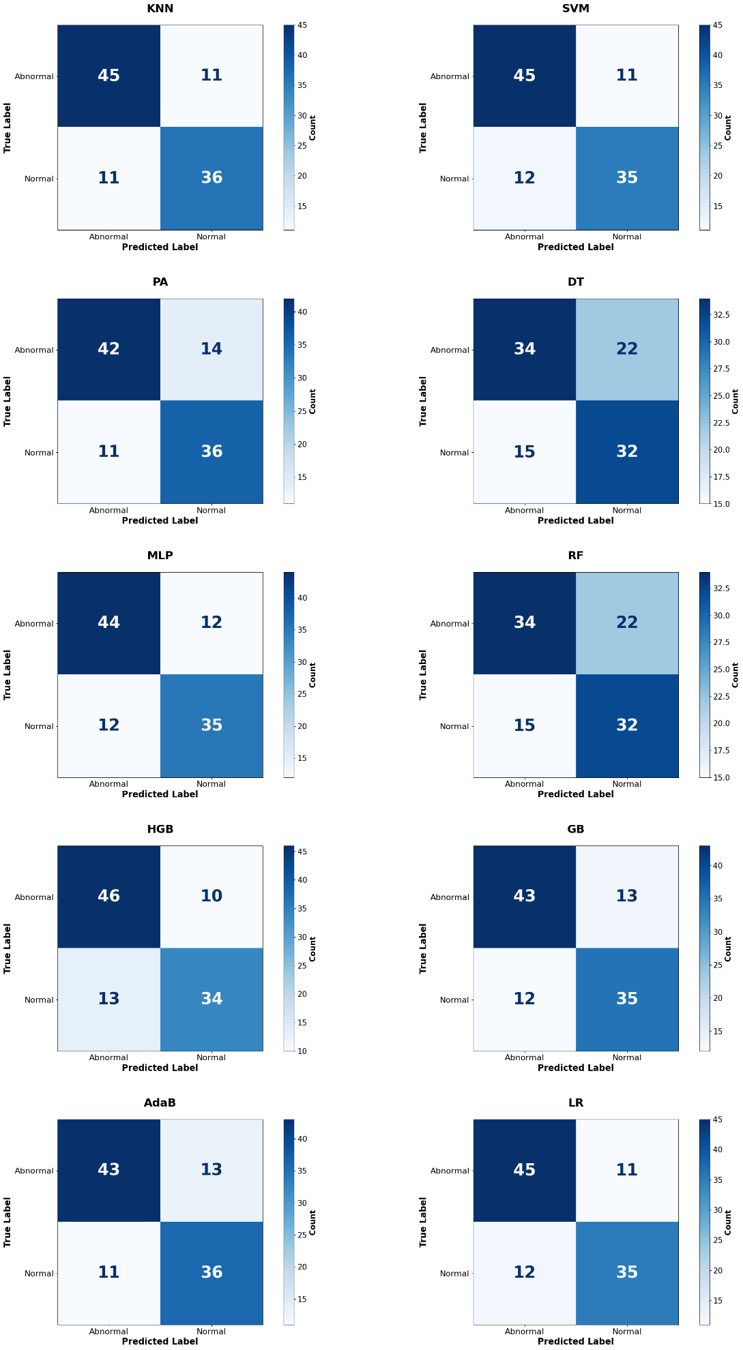